# Simulating data with the Joint Model

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from tslearn.metrics import cdist_dtw
import umap

from leaspy.io.data import Data
from leaspy.datasets import load_dataset

## Import Data



In [2]:
df = load_dataset("simulated_data_for_joint")
display(df.head())
print(df.columns)

EVENT_TIME  EVENT_BOOL       Y0    Y1   Y2   Y3
ID  TIME                                                   
116 78.461        85.5           1  0.44444  0.04  0.0  0.0
    78.936        85.5           1  0.60000  0.00  0.0  0.2
    79.482        85.5           1  0.39267  0.04  0.0  0.2
    79.939        85.5           1  0.58511  0.00  0.0  0.0
    80.491        85.5           1  0.57044  0.00  0.0  0.0

Index(['EVENT_TIME', 'EVENT_BOOL', 'Y0', 'Y1', 'Y2', 'Y3'], dtype='object')


To use the Joint Model in Leaspy, your dataset must include the following columns:

1. **ID** : Patient identifier
2. **TIME** : Time of measurement
3. **EVENT_TIME** : Time of the event
4. **EVENT_BOOL** : Event indicator:
   - `1` if the event occurred
   - `0` if censored
   - `2` if a competing event occurred

For one patient, the event time and event bool are the same for each row.



## Joint Model Initialization and Fitting

In [3]:
from leaspy.models import JointModel

data = Data.from_dataframe(df, "joint")
model = JointModel(name="joint", nb_events=1)

In [4]:
N = 1
model.fit(data, "mcmc_saem", seed=1312, n_iter=N, progress_bar=True, plot_periodicity=200, save_periodicity=100) 

 ==> Setting seed to 1312
|#|   1/1 iterations

Fit with `AlgorithmName.FIT_MCMC_SAEM` took: 0s


In [5]:
print(model.parameters)

{'betas_mean': tensor([[-0.0040,  0.0004],
        [-0.0105,  0.0032],
        [ 0.0037,  0.0030]]), 'log_g_mean': tensor([0.1115, 2.8583, 2.5473, 1.1294]), 'log_rho_mean': tensor([2.0267]), 'log_v0_mean': tensor([-3.1870, -3.8499, -4.0026, -3.0772]), 'n_log_nu_mean': tensor([-2.1362]), 'noise_std': tensor(0.1968, dtype=torch.float64), 'tau_mean': tensor([75.5033], dtype=torch.float64), 'tau_std': tensor([6.0432], dtype=torch.float64), 'xi_std': tensor([0.1103], dtype=torch.float64), 'zeta_mean': tensor([[ 0.0050],
        [-0.0045]])}


In [6]:
model.save(f"../models/model_on_simulated_data_for_joint_{N}_iterations.json")

## Simulation

The parameters for simulating patient visits are defined.
These parameters specify the number of patients, the visit spacing, and the timing variability.

In [7]:
visit_params = {
    "patient_number": 50,
    "visit_type": "random",
    "data": data
}

In [8]:
df_sim = model.simulate(
    algorithm="joint_simulate",
    features=["Y0", "Y1", "Y2", "Y3"],
    visit_parameters=visit_params,
)

  [joint_simulate] Parameter 'first_visit_mean' not provided, estimated from data: -0.0
  [joint_simulate] Parameter 'first_visit_std' not provided, estimated from data: 5.7495
  [joint_simulate] Parameter 'time_follow_up_mean' not provided, estimated from data: 6.4194
  [joint_simulate] Parameter 'time_follow_up_std' not provided, estimated from data: 1.2036
  [joint_simulate] Parameter 'distance_visit_mean' not provided, estimated from data: 0.7795
  [joint_simulate] Parameter 'distance_visit_std' not provided, estimated from data: 0.2982
  [joint_simulate] Parameter 'min_spacing_between_visits' not provided, estimated from data: 0.328

Simulate with `joint_simulate` took: 0s


In [9]:
df_sim = df_sim.data.to_dataframe()

display(df_sim)

,ID,TIME,EVENT_TIME,EVENT_BOOL,Y0,Y1,Y2,Y3
0,0,61.3,67.649415,0,0.163311,0.000000,0.000000,2.356818e-30
1,0,62.0,67.649415,0,0.145782,0.000000,0.000000,1.489336e-04
2,0,62.6,67.649415,0,0.132013,0.000000,0.000000,1.169089e-17
3,0,63.3,67.649415,0,0.579662,0.000000,0.000000,1.586911e-02
4,0,64.2,67.649415,0,0.518111,1.000000,0.000000,1.612163e-03
...,...,...,...,...,...,...,...,...
360,49,80.1,84.573856,1,0.836744,0.385057,0.101459,2.246463e-01
361,49,81.2,84.573856,1,0.765921,0.478617,0.163885,5.805826e-01
362,49,82.4,84.573856,1,0.868860,0.432103,0.269887,8.244960e-01
363,49,83.4,84.573856,1,0.736645,0.870792,0.554504,9.914722e-01


In [10]:
len(df_sim[df_sim["EVENT_BOOL"] == 0])

242

## Representation witb DTW + UMAP

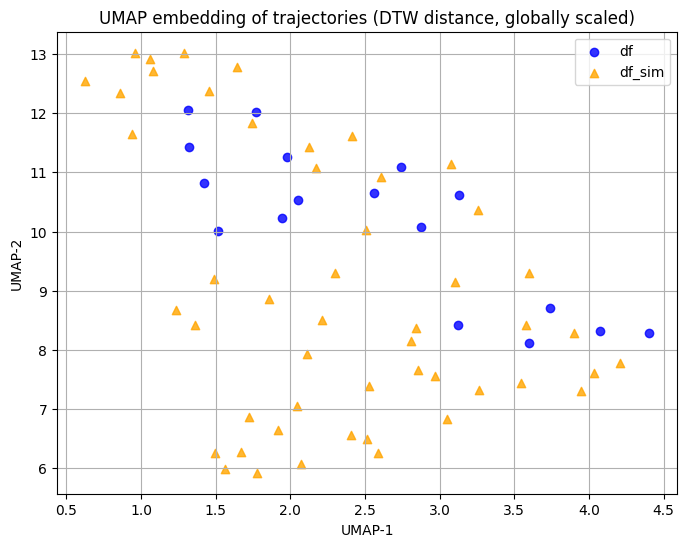

In [11]:
# 1. Build trajectories
def build_trajectories(df):
    traj = []
    ids = []
    
    for id_, g in df.groupby('ID'):
        g = g.sort_values('TIME')
        X = g[['Y0','Y1','Y2','Y3']].values
        
        traj.append(X)
        ids.append(id_)
        
    return traj, ids

traj_df, ids_df = build_trajectories(df)
traj_sim, ids_sim = build_trajectories(df_sim)

# Combine
X_all = traj_df + traj_sim
labels = np.array(['df']*len(traj_df) + ['df_sim']*len(traj_sim))

# 2. Normalize globally (fit on all observations combined to preserve scale differences)
all_values = np.vstack(X_all)
scaler = StandardScaler()
scaler.fit(all_values)
scaled_traj = [scaler.transform(X) for X in X_all]

# 3. DTW distance matrix
D = cdist_dtw(scaled_traj)

# 4. UMAP on distance matrix
embedding = umap.UMAP(
    metric='precomputed',
    n_neighbors=15,
    min_dist=0.2,
    random_state=42
).fit_transform(D)

# 5. Plot
mask_df = labels == 'df'
mask_sim = labels == 'df_sim'

plt.figure(figsize=(8,6))

plt.scatter(
    embedding[mask_df, 0],
    embedding[mask_df, 1],
    c='blue',
    marker='o',
    label='df',
    alpha=0.8
)

plt.scatter(
    embedding[mask_sim, 0],
    embedding[mask_sim, 1],
    c='orange',
    marker='^',
    label='df_sim',
    alpha=0.8
)

plt.title("UMAP embedding of trajectories (DTW distance, globally scaled)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.grid(True)

plt.show()
